# routeFigure v10 (260930) — 논문 게재용 경로 그림

| 항목 | 내용 |
| --- | --- |
| 목적 | 출발지·도착지·선정 경유지·회피 영역·회피구간 통과를 한 장에 표시한 그림 생성 |
| 대상 절 | 논문 2.1 / 3.1 (경로 추천 알고리즘) |
| 알고리즘 | v6와 동일 (방법 C + Safe Swap). 셀 5~9는 `avoidZoneTest_v6_260827.ipynb`에서 그대로 복사 |
| 표본 | v6 혼합 표본 200쌍 (`mixed_od_200.pkl`) 재사용 |
| K | 2 (v6 스윕 결과 확정값) |
| Tmap 호출 | 대표 OD 1개당 최대 6회 (원본 1 + 회피 적용 최대 5). 한도 부담 없음 |
| 산출물 | `./output10_260930/figures/` |

---

## 왜 별도 노트북인가

v6는 K 스윕 실행 노트북이며, 셀 16이 `RUN_K`에 따라 **Tmap을 600~1,100회 호출**한다.
그림은 OD를 바꿔가며 여러 번 그리는 작업이므로, 그 셀과 같은 파일에 두면 오실행 위험에 반복 노출된다.
알고리즘 정의 셀만 복사해 별도 노트북으로 분리한다.

**알고리즘 셀은 재작성하지 않고 v6에서 그대로 복사하였다.** 미세하게 달라지면
그림이 실제 측정한 것과 다른 동작을 보이게 된다.

## 선행 조건

작업 폴더에 아래가 있어야 한다. 경로는 v6와 동일하다.

```
./hotspots_CCTV_20260510.csv
./output/incheon_avoid_zones_v1_260601.geojson
./output6_260827/mixed_od_200.pkl
./output6_260827/k2/k2_result.csv      (선택 — 있으면 OD를 자동 선정한다)
.env 의 TMAP_APP_KEY
```

## 그림 설계

| 항목 | 방침 |
| --- | --- |
| 배경 지도 타일 | **사용하지 않는다.** 이용 약관 확인이 필요하고, 한 단 폭에서 지명이 판독되지 않는다 |
| 공간 정보 | 회피 영역 폴리곤 + 축척 막대로 전달한다 |
| 색 의존 | 선 종류(실선/점선)와 마커 모양(사각/삼각/원)으로 중복 부호화하여 흑백 인쇄에서도 판독된다 |
| 투영 | 국소 평면(km). 위경도를 그대로 쓰면 위도 37도에서 동서가 약 26% 과대 표시된다. 표시 전용 보정이며 알고리즘 수치와 무관하다 |
| 타원 회랑 | 실제 판정식 그대로. 초점 O·D, 장축합 `d(O,D) + 2.25km / 1.3` |

## 배치

셀 12가 **두 배치를 한 번에 생성**한다. 경로 산출(Tmap)은 한 번만 하므로 호출 수는 배치 하나일 때와 같다.

| 배치 | 용도 | 폭 |
| --- | --- | --- |
| `single` | 두 경로를 한 장에 겹침 | 약 8.5cm (2단 한 단) |
| `dual` | (a) 회피 미적용 / (b) 회피 적용 | 약 18cm (2단 전체) |

## 실행 순서

셀 1부터 12까지 차례로 실행한다. 셀 13은 선택이며, 후보 OD 5개를 한꺼번에 그려 비교표를 출력한다.


In [1]:
# 셀 1: 라이브러리 import 및 환경 점검
# v6와 동일한 스택을 사용한다 (알고리즘 셀을 그대로 복사하므로)

# 표준 라이브러리
import os
import json
import time
import math
import itertools
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

# HTTP·환경
import requests
from dotenv import load_dotenv

# 데이터 처리
import numpy as np
import pandas as pd

# 거리·공간 처리
from shapely.geometry import shape, Point, LineString
from shapely.ops import unary_union
from shapely.prepared import prep
from scipy.spatial import cKDTree   # neighbor_200m 계산용 (sklearn BallTree 대체)

# 지도 시각화
import folium

print(f"[v10 노트북 시작 — 논문 게재용 경로 그림]")
print(f"  pandas    {pd.__version__}")
print(f"  numpy     {np.__version__}")
print(f"  folium    {folium.__version__}")
print(f"  requests  {requests.__version__}")
print(f"  작업 디렉토리: {os.getcwd()}")

[v10 노트북 시작 — 논문 게재용 경로 그림]
  pandas    3.0.3
  numpy     2.4.6
  folium    0.20.0
  requests  2.34.2
  작업 디렉토리: c:\Users\User\Documents\GitHub\ploggo-algorithm-test


In [2]:
# 셀 2: 인증키 로드 + 입출력 경로 점검

import pickle

load_dotenv(override=True)

TMAP_APP_KEY = os.getenv('TMAP_APP_KEY')
if not TMAP_APP_KEY:
    raise RuntimeError(".env에 TMAP_APP_KEY가 없다. 도보 경로 산출에 필요하다.")
print(f"[인증키] Tmap {TMAP_APP_KEY[:6]}...{TMAP_APP_KEY[-4:]} ({len(TMAP_APP_KEY)}자)")

# --- 입력 (v1·v6 산출물을 그대로 참조한다) ---
CSV_PATH       = Path("./hotspots_CCTV_20260510.csv")
GEOJSON_PATH   = Path("./output/incheon_avoid_zones_v1_260601.geojson")
OD_PKL_PATH    = Path("./output6_260827/mixed_od_200.pkl")
K2_RESULT_PATH = Path("./output6_260827/k2/k2_result.csv")   # OD 자동 선정용(없어도 동작)

# --- 출력 ---
STAMP    = "260930"
V10_ROOT = Path(f"./output10_{STAMP}")
V10_ROOT.mkdir(parents=True, exist_ok=True)

_missing = [p for p in (CSV_PATH, GEOJSON_PATH, OD_PKL_PATH) if not p.exists()]
if _missing:
    raise FileNotFoundError(
        "입력 파일이 없다:\n  " + "\n  ".join(str(p.resolve()) for p in _missing))

print("\n[입력 파일]")
for p in (CSV_PATH, GEOJSON_PATH, OD_PKL_PATH):
    print(f"  {p}  ({p.stat().st_size/1024:.0f} KB)")
print(f"  {K2_RESULT_PATH}  "
      f"{'있음 — OD 자동 선정에 사용' if K2_RESULT_PATH.exists() else '없음 — 폴백 선정'}")
print(f"\n[출력 폴더] {V10_ROOT.resolve()}")

[인증키] Tmap r8mALt...H5Zm (40자)

[입력 파일]
  hotspots_CCTV_20260510.csv  (334 KB)
  output\incheon_avoid_zones_v1_260601.geojson  (1719 KB)
  output6_260827\mixed_od_200.pkl  (1347 KB)
  output6_260827\k2\k2_result.csv  있음 — OD 자동 선정에 사용

[출력 폴더] C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output10_260930


In [3]:
# 셀 3: v1 회피 영역 GeoJSON 로드 + shapely 변환
# v1 노트북에서 V-World로 수집한 147개 폴리곤을 그대로 활용 (시간 절약)

from shapely.geometry import shape
from shapely.ops import unary_union
from shapely.prepared import prep

# v1 산출물 경로 (output 폴더에 있음)
GEOJSON_PATH = Path("./output/incheon_avoid_zones_v1_260601.geojson")

if not GEOJSON_PATH.exists():
    raise FileNotFoundError(
        f"v1 GeoJSON 파일이 없다: {GEOJSON_PATH.resolve()}\n"
        f"v1 노트북의 셀 11까지 실행한 산출물이 있어야 한다."
    )

with open(GEOJSON_PATH, 'r', encoding='utf-8') as f:
    avoid_geojson = json.load(f)

# 147개 features → shapely 폴리곤 + 메타데이터
avoid_polygons = []
for feature in avoid_geojson['features']:
    props = feature['properties']
    geom = shape(feature['geometry'])
    avoid_polygons.append({
        'geom':       geom,
        'uqa_code':   props.get('uqa_code'),
        'uname':      props.get('uname'),
        'sigg_name':  props.get('sigg_name'),
        'feature_id': props.get('feature_id'),
    })

# 전체 폴리곤 union (교차 검사·페널티 계산용)
avoid_union = unary_union([p['geom'] for p in avoid_polygons])
avoid_union_prepared = prep(avoid_union)  # 점-폴리곤 검사 가속

# UQA 코드별 union (분석용)
avoid_union_by_code = {}
for code in ['UQA310', 'UQA320', 'UQA330']:
    geoms = [p['geom'] for p in avoid_polygons if p['uqa_code'] == code]
    if geoms:
        avoid_union_by_code[code] = unary_union(geoms)

# 통계 출력
print(f"[회피 영역 로드 완료]")
print(f"  총 폴리곤: {len(avoid_polygons)}개")
print(f"  UQA 코드별:")
for code in ['UQA310', 'UQA320', 'UQA330']:
    n = sum(1 for p in avoid_polygons if p['uqa_code'] == code)
    print(f"    {code}: {n}개")

print(f"\n  군구별:")
sigg_counts = Counter(p['sigg_name'] for p in avoid_polygons)
for sigg, n in sigg_counts.most_common():
    print(f"    {sigg:<15} {n}개")

print(f"\n  avoid_union bounds (lon_min, lat_min, lon_max, lat_max):")
print(f"    {avoid_union.bounds}")

[회피 영역 로드 완료]
  총 폴리곤: 147개
  UQA 코드별:
    UQA310: 5개
    UQA320: 46개
    UQA330: 96개

  군구별:
    서구              44개
    중구              29개
    미추홀구            15개
    남동구             14개
    동구              12개
    계양구             12개
    연수구             11개
    부평구             7개
    강화군             3개

  avoid_union bounds (lon_min, lat_min, lon_max, lat_max):
    (126.47063840934426, 37.34180714965152, 126.76623837593196, 37.767857612646296)


In [4]:
# 셀 4: 핫스팟 CSV 로드 + neighbor_200m + S_i 계산
# routeTest_v3 셀 3·5·6 이식 (핸드오프 v4 알고리즘 사양 그대로)

import ast
from scipy.spatial import cKDTree

# === 1. CSV 로드 ===
CSV_PATH = Path("./hotspots_CCTV_20260510.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError(f"핫스팟 CSV가 없다: {CSV_PATH.resolve()}")

hotspots = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

# list 필드 복원 (문자열 → list)
def parse_list_field(value):
    if pd.isna(value):
        return None
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return None
    return value

hotspots['install_years']      = hotspots['install_years'].apply(parse_list_field)
hotspots['relocation_history'] = hotspots['relocation_history'].apply(parse_list_field)

print(f"[핫스팟 로드] {len(hotspots):,}곳, {len(hotspots.columns)}컬럼")

# === 2. neighbor_200m 계산 (cKDTree) ===
# 핸드오프 D2-2 공식: S_i = cctv_count + 0.5 × neighbor_200m
EARTH_RADIUS_KM = 6371.0

t0 = time.time()
# 위경도를 3차원 단위구 좌표로 변환한 뒤, 대원거리에 대응하는 현(chord) 거리로
# 반경 질의한다. sklearn BallTree(metric='haversine')와 수치적으로 동일하며
# (좌표 3,000개 전수 비교 검증 완료), Windows 앱 제어 정책이 sklearn의 컴파일된
# DLL을 차단하는 환경에서도 동작한다.
_lat_rad = np.radians(hotspots['latitude'].values)
_lon_rad = np.radians(hotspots['longitude'].values)
_xyz = np.column_stack([
    np.cos(_lat_rad) * np.cos(_lon_rad),
    np.cos(_lat_rad) * np.sin(_lon_rad),
    np.sin(_lat_rad),
])
tree = cKDTree(_xyz)
radius_rad = 0.2 / EARTH_RADIUS_KM          # 200m → 라디안
chord = 2 * np.sin(radius_rad / 2)          # 라디안 → 단위구 현 거리

# query_ball_point는 자기 자신 포함 카운트 반환 → -1 보정
counts = tree.query_ball_point(_xyz, r=chord, return_length=True)
hotspots['neighbor_200m'] = counts - 1

print(f"\n[neighbor_200m 계산] 소요 {time.time() - t0:.2f}초")
print(f"  분포: min {hotspots['neighbor_200m'].min()}, "
      f"max {hotspots['neighbor_200m'].max()}, "
      f"평균 {hotspots['neighbor_200m'].mean():.2f}")

n_with_neighbor = (hotspots['neighbor_200m'] > 0).sum()
print(f"  200m 내 이웃 보유: {n_with_neighbor:,}곳 ({n_with_neighbor/len(hotspots)*100:.1f}%)")

# === 3. S_i 계산 ===
hotspots['S_i'] = hotspots['cctv_count'] + 0.5 * hotspots['neighbor_200m']

print(f"\n[S_i 계산 완료]")
print(f"  분포: min {hotspots['S_i'].min():.2f}, "
      f"max {hotspots['S_i'].max():.2f}, "
      f"평균 {hotspots['S_i'].mean():.2f}")

print(f"\n  군구별 S_i 평균:")
for sigg, mean_si in hotspots.groupby('source_district')['S_i'].mean().items():
    print(f"    {sigg:<12} {mean_si:.2f}")

# === 4. 회피 영역 내부 핫스팟 표시 (방법 C에서 활용) ===
# 각 핫스팟이 회피 영역 내부에 있는지 미리 계산
def is_in_avoid_zone(row):
    pt = Point(row['longitude'], row['latitude'])
    return avoid_union_prepared.contains(pt)

t0 = time.time()
hotspots['in_avoid_zone'] = hotspots.apply(is_in_avoid_zone, axis=1)
print(f"\n[회피 영역 내부 검사] 소요 {time.time() - t0:.2f}초")
print(f"  회피 영역 내부 핫스팟: {hotspots['in_avoid_zone'].sum()}/{len(hotspots):,} "
      f"({hotspots['in_avoid_zone'].sum()/len(hotspots)*100:.2f}%)")

[핫스팟 로드] 1,535곳, 15컬럼

[neighbor_200m 계산] 소요 0.00초
  분포: min 0, max 17, 평균 3.16
  200m 내 이웃 보유: 1,178곳 (76.7%)

[S_i 계산 완료]
  분포: min 1.00, max 11.00, 평균 2.78

  군구별 S_i 평균:
    bupyeong     1.25
    donggu       1.88
    ganghwa      1.07
    gyeyang      3.51
    junggu       1.94
    michuhol     2.11
    namdong      1.70
    seogu        2.65
    yeonsu       4.86

[회피 영역 내부 검사] 소요 0.03초
  회피 영역 내부 핫스팟: 58/1,535 (3.78%)


---

### 셀 5 ~ 9 — v6 알고리즘 정의 (복사본)

아래 다섯 셀은 `avoidZoneTest_v6_260827.ipynb`의 셀 5·6·7·8·9·11(수정판)에서
**함수 정의부만 그대로 복사**한 것이다. 9 OD 동작 검증 출력은 본 노트북에 불필요하여 제외하였다.
알고리즘 동작은 v6와 완전히 동일하다.


In [5]:
# 셀 5: 거리·Buffer 유틸 함수 (v6 셀 5 복사 — 함수 정의부만)
# haversine 패키지 의존 제거 — numpy 기반 직접 구현 (수학적으로 동일)

# === 0. Haversine 직접 구현 ===
def haversine_km(p_a, p_b):
    """두 (lat, lon) 좌표 사이의 Haversine 거리 (km)
    
    haversine 패키지의 hs.haversine(p_a, p_b, unit=hs.Unit.KILOMETERS)와 동일 결과.
    지구 반경 6371.0 km 사용.
    """
    lat1, lon1 = p_a
    lat2, lon2 = p_b
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    return EARTH_RADIUS_KM * c   # EARTH_RADIUS_KM은 셀 4에서 6371.0으로 정의됨

# === 1. 도보·Buffer 유틸 함수 ===
DETOUR_RATIO = 1.3   # 한국 도시 도보 환경 평균 보정계수 (핸드오프 D3)

def walking_distance_km(p_a, p_b):
    """추정 도보 거리 (km) = Haversine × 1.3"""
    return haversine_km(p_a, p_b) * DETOUR_RATIO

def detour_distance_km(origin, hotspot, destination):
    """핫스팟 단독 경유 시 우회 거리: D_i = d(O,h) + d(h,D) - d(O,D)"""
    d_oh = walking_distance_km(origin, hotspot)
    d_hd = walking_distance_km(hotspot, destination)
    d_od = walking_distance_km(origin, destination)
    return max(d_oh + d_hd - d_od, 0.0)

def get_buffer_radius(district):
    """군구별 buffer 반경 (km) — 강화군 2.5km, 그 외 1.5km (핸드오프 D4)"""
    return 2.5 if district == 'ganghwa' else 1.5

def filter_candidates_by_ellipse_buffer(df, origin, destination, buffer_r_km):
    """타원 buffer 필터링: d(O,h) + d(h,D) - d(O,D) < buffer_r × 1.5"""
    d_od = walking_distance_km(origin, destination)
    threshold = buffer_r_km * 1.5
    
    coords = df[['latitude', 'longitude']].values
    d_oh = np.array([walking_distance_km(origin, tuple(c)) for c in coords])
    d_hd = np.array([walking_distance_km(tuple(c), destination) for c in coords])
    
    mask = (d_oh + d_hd - d_od) < threshold
    return df[mask].copy()

In [6]:
# 셀 6: 정적 회피 페널티 함수 (방법 C 핵심)
# Tmap 호출 없이 shapely 직선 교차로 회피 페널티 계산
# 위경도 1도 ≈ 111km (위도 37도 부근) 근사 사용

def compute_avoid_penalty(hotspot_lat, hotspot_lon, origin, destination,
                          avoid_union, avoid_union_prepared):
    """
    핫스팟의 정적 회피 페널티 계산.
    
    구성 요소:
    1. 핫스팟이 회피 영역 내부면 매우 큰 페널티 (999) — 옵션 X 완전 차단
    2. O → 핫스팟 직선의 회피 영역 통과 길이
    3. 핫스팟 → D 직선의 회피 영역 통과 길이
    
    단위: km (다른 항과 일치)
    호출 비용: O(1), 약 1~2 밀리초
    
    Args:
        hotspot_lat, hotspot_lon: 핫스팟 좌표
        origin: (lat, lon) 출발지
        destination: (lat, lon) 도착지
        avoid_union: shapely MultiPolygon (회피 영역 union)
        avoid_union_prepared: prep된 union (점-폴리곤 검사 가속)
    
    Returns:
        float: 페널티 (km)
    """
    # 1. 회피 영역 내부 검사 (옵션 X 차단)
    hotspot_point = Point(hotspot_lon, hotspot_lat)
    if avoid_union_prepared.contains(hotspot_point):
        return 999.0
    
    # 2. O → 핫스팟 직선의 회피 영역 통과
    line_o = LineString([
        (origin[1], origin[0]),
        (hotspot_lon, hotspot_lat),
    ])
    inter_o = line_o.intersection(avoid_union)
    len_o_deg = inter_o.length if not inter_o.is_empty else 0
    
    # 3. 핫스팟 → D 직선의 회피 영역 통과
    line_d = LineString([
        (hotspot_lon, hotspot_lat),
        (destination[1], destination[0]),
    ])
    inter_d = line_d.intersection(avoid_union)
    len_d_deg = inter_d.length if not inter_d.is_empty else 0
    
    # 위경도 → km 근사 (위도 37도 부근 1도 ≈ 111km)
    return (len_o_deg + len_d_deg) * 111.0

In [7]:
# 셀 7: Score 공식 + Greedy 선정 (v6 셀 7·8 복사 — 함수 정의부만)
# 새 공식: Score_i = α·S_i - β·D_i - γ·avoid_penalty_i

# === 하이퍼파라미터 ===
ALPHA = 0.5   # S_i 가중치 (핸드오프 D6 그대로)
BETA  = 0.5   # D_i 가중치 (핸드오프 D6 그대로)
GAMMA = 1.0   # avoid_penalty 가중치 (방법 C 신규, 단계 6 후반 튜닝 대상)

# === 회피 페널티 통합 Score 함수 (방법 C) ===
def compute_scores_with_avoidance(df, origin, destination,
                                   avoid_union, avoid_union_prepared,
                                   alpha=ALPHA, beta=BETA, gamma=GAMMA):
    """방법 C 적용 Score 계산.
    Score_i = α·S_i - β·D_i - γ·avoid_penalty_i
    """
    out = df.copy()
    out['D_i'] = out.apply(
        lambda r: detour_distance_km(origin, (r['latitude'], r['longitude']), destination),
        axis=1
    )
    out['avoid_penalty_i'] = out.apply(
        lambda r: compute_avoid_penalty(
            r['latitude'], r['longitude'],
            origin, destination,
            avoid_union, avoid_union_prepared,
        ),
        axis=1
    )
    out['Score_i'] = alpha * out['S_i'] - beta * out['D_i'] - gamma * out['avoid_penalty_i']
    return out

# === 원본 Score 함수 (방법 C 적용 전, 회귀 검증용) ===
def compute_scores_original(df, origin, destination, alpha=ALPHA, beta=BETA):
    """routeTest_v3 원본 Score (회귀 검증용)."""
    out = df.copy()
    out['D_i'] = out.apply(
        lambda r: detour_distance_km(origin, (r['latitude'], r['longitude']), destination),
        axis=1
    )
    out['avoid_penalty_i'] = 0.0   # 없음 (호환성)
    out['Score_i'] = alpha * out['S_i'] - beta * out['D_i']
    return out

print(f"[Score 공식 정의 완료]")
print(f"  원본: Score_i = α·S_i - β·D_i")
print(f"  방법 C: Score_i = α·S_i - β·D_i - γ·avoid_penalty_i")
print(f"  가중치: α={ALPHA}, β={BETA}, γ={GAMMA} (초기값)")
print(f"  γ = 1.0 확정 (v3에서 0.5~5.0 스윕, 85%에서 결과 동일)")


# --- Greedy 선정 (v6 셀 8) ---
# K는 v6 스윕 결과 2로 확정하였다. 그림 셀은 FIG_K로 명시 전달하므로
# 아래 값은 기본값으로만 쓰인다.

K = 2
BF_TOP_N = 15

def algorithm_greedy_v2(candidates_df, origin, destination,
                         avoid_union, avoid_union_prepared,
                         alpha=ALPHA, beta=BETA, gamma=GAMMA, k=K):
    """방법 C 적용 Greedy.
    1. S_i 상위 BF_TOP_N=15 풀 (원본과 동일)
    2. compute_scores_with_avoidance로 Score_i 계산 (회피 페널티 포함)
    3. Score_i 상위 K=3 선택
    """
    t0 = time.time()
    n = len(candidates_df)
    if n == 0:
        return pd.DataFrame(), 0
    k_eff = min(k, n)
    
    pool = candidates_df.nlargest(min(BF_TOP_N, n), 'S_i')
    scored = compute_scores_with_avoidance(
        pool, origin, destination, avoid_union, avoid_union_prepared,
        alpha=alpha, beta=beta, gamma=gamma,
    )
    selected = scored.nlargest(k_eff, 'Score_i')
    return selected, (time.time() - t0) * 1000

def algorithm_greedy_original(candidates_df, origin, destination,
                               alpha=ALPHA, beta=BETA, k=K):
    """routeTest_v3 원본 Greedy (회귀 검증용)."""
    t0 = time.time()
    n = len(candidates_df)
    if n == 0:
        return pd.DataFrame(), 0
    k_eff = min(k, n)
    
    pool = candidates_df.nlargest(min(BF_TOP_N, n), 'S_i')
    scored = compute_scores_original(pool, origin, destination, alpha=alpha, beta=beta)
    selected = scored.nlargest(k_eff, 'Score_i')
    return selected, (time.time() - t0) * 1000

[Score 공식 정의 완료]
  원본: Score_i = α·S_i - β·D_i
  방법 C: Score_i = α·S_i - β·D_i - γ·avoid_penalty_i
  가중치: α=0.5, β=0.5, γ=1.0 (초기값)
  γ = 1.0 확정 (v3에서 0.5~5.0 스윕, 85%에서 결과 동일)


In [8]:
# 셀 8: Tmap 보행자 호출 + polyline 교차 검사 (v6 셀 9 복사)

TMAP_PEDESTRIAN_URL = "https://apis.openapi.sk.com/tmap/routes/pedestrian?version=1"

def get_pedestrian_route(origin, destination, waypoints=None, debug=False):
    """Tmap 보행자 경로안내 API 호출.
    
    Args:
        origin, destination: (lat, lon)
        waypoints: [(lat, lon), ...] 또는 None (최대 5개)
    Returns:
        dict: path([(lat, lon), ...]), distance_m, duration_ms, status
    """
    headers = {
        "Accept": "application/json",
        "Content-Type": "application/json",
        "appKey": TMAP_APP_KEY,
    }
    payload = {
        "startX": origin[1], "startY": origin[0],
        "endX": destination[1], "endY": destination[0],
        "startName": "출발지", "endName": "도착지",
        "reqCoordType": "WGS84GEO", "resCoordType": "WGS84GEO",
        "searchOption": "0",
    }
    if waypoints:
        if len(waypoints) > 5:
            return {'path': None, 'distance_m': 0, 'duration_ms': 0,
                    'status': f'ERROR: 경유지 {len(waypoints)}개. Tmap 한도 5개 초과'}
        payload["passList"] = "_".join(f"{wp[1]},{wp[0]}" for wp in waypoints)
    
    try:
        r = requests.post(TMAP_PEDESTRIAN_URL, headers=headers, json=payload, timeout=15)
    except requests.exceptions.RequestException as e:
        return {'path': None, 'distance_m': 0, 'duration_ms': 0,
                'status': f'ERROR: {type(e).__name__}'}
    
    if r.status_code != 200:
        return {'path': None, 'distance_m': 0, 'duration_ms': 0,
                'status': f'ERROR: HTTP {r.status_code}, body: {r.text[:150]}'}
    
    try:
        result = r.json()
    except json.JSONDecodeError:
        return {'path': None, 'distance_m': 0, 'duration_ms': 0, 'status': 'JSON_ERROR'}
    
    if result.get('type') != 'FeatureCollection':
        return {'path': None, 'distance_m': 0, 'duration_ms': 0, 'status': 'INVALID'}
    
    features = result.get('features', [])
    if not features:
        return {'path': None, 'distance_m': 0, 'duration_ms': 0, 'status': 'NO_FEATURES'}
    
    first_props = features[0].get('properties', {})
    total_distance_m = first_props.get('totalDistance', 0)
    total_time_s = first_props.get('totalTime', 0)
    
    path_lonlat = []
    for f in features:
        geom = f.get('geometry', {})
        if geom.get('type') == 'LineString':
            path_lonlat.extend(geom.get('coordinates', []))
    
    # (lat, lon) 형식으로 변환 (본 노트북 일관성)
    path_latlon = [(pt[1], pt[0]) for pt in path_lonlat]
    
    return {
        'path': path_latlon,
        'distance_m': total_distance_m,
        'duration_ms': total_time_s * 1000,
        'status': 'OK',
    }


def check_polyline_avoid_intersection(path_latlon, avoid_union_param, 
                                        avoid_union_by_code_param):
    """polyline이 회피 영역과 교차하는지 검사.
    
    Args:
        path_latlon: [(lat, lon), ...] polyline 좌표 리스트
        avoid_union_param: shapely MultiPolygon (전체 회피 영역)
        avoid_union_by_code_param: dict {uqa_code: union} (코드별 회피 영역)
    
    Returns:
        dict: crosses, intersection_length_m, intersection_ratio, crossed_uqa_codes
    """
    empty_result = {
        'crosses': False, 'intersection_length_m': 0, 
        'intersection_ratio': 0, 'crossed_uqa_codes': [],
    }
    
    if not path_latlon or len(path_latlon) < 2:
        return empty_result
    
    # polyline → shapely LineString (lon, lat 순서)
    line = LineString([(pt[1], pt[0]) for pt in path_latlon])
    
    if not line.intersects(avoid_union_param):
        return empty_result
    
    intersection = line.intersection(avoid_union_param)
    inter_length_m = intersection.length * 111000.0
    total_length_m = line.length * 111000.0
    ratio = inter_length_m / total_length_m if total_length_m > 0 else 0
    
    # 어느 UQA 코드와 교차?
    crossed_codes = []
    for code, union in avoid_union_by_code_param.items():
        if line.intersects(union):
            crossed_codes.append(code)
    
    return {
        'crosses': True,
        'intersection_length_m': inter_length_m,
        'intersection_ratio': ratio,
        'crossed_uqa_codes': crossed_codes,
    }

In [9]:
# 셀 9: 방법 C + Safe Swap 통합 알고리즘 (v6 셀 11 수정판 복사)
# 매 시도의 최선 결과를 추적하여, 후보 교체가 결과를 악화시킬 수 없다.

MAX_SWAP_ATTEMPTS = 5   # swap 최대 시도 횟수 (v6와 동일)

def algorithm_greedy_with_avoidance(candidates_df, origin, destination,
                                      avoid_union_param, avoid_union_prepared_param,
                                      avoid_union_by_code_param,
                                      alpha=ALPHA, beta=BETA, gamma=GAMMA,
                                      k=K, max_swap=MAX_SWAP_ATTEMPTS,
                                      verbose=False):
    """방법 C + swap 통합 알고리즘 (4번째 알고리즘 후보 E_v2).
    
    파이프라인:
    1. Buffer 후보 → S_i Top-15 풀
    2. 방법 C: Score_i = α·S_i - β·D_i - γ·avoid_penalty_i
    3. Score_i Top-K=3 초기 선정
    4. K=3을 Score_i 내림차순으로 방문
    5. Tmap polyline 호출 + 교차 검사
    6. 교차 시 swap (penalty 큰 후보 → 다음 Score 후보)
    7. ★ 매 attempt마다 best 추적 → 최종적으로 best 반환
    8. 최대 max_swap회까지 반복 후 hard case 종료
    
    수정 (단계 6-α 발견 반영):
    - 최선 결과 추적 (best dict)
    - swap이 결과를 악화시켜도 baseline(또는 더 좋은) 결과 보장
    - 'best_from_attempt' 필드 추가 — 어느 attempt가 best였는지 명시
    
    Returns:
        dict: final_selection, visit_order, final_polyline, final_intersection,
              final_distance_m, final_duration_ms, n_swaps, hard_case,
              swap_history, total_elapsed_ms, best_from_attempt
    """
    t0 = time.time()
    
    # 1. S_i Top-15 풀
    n = len(candidates_df)
    if n == 0:
        return None
    pool = candidates_df.nlargest(min(BF_TOP_N, n), 'S_i')
    
    # 2. 방법 C: Score_i 계산
    scored_pool = compute_scores_with_avoidance(
        pool, origin, destination,
        avoid_union_param, avoid_union_prepared_param,
        alpha=alpha, beta=beta, gamma=gamma,
    )
    
    # 3. Score_i Top-K=3 초기 선정
    k_eff = min(k, n)
    initial_selection = scored_pool.nlargest(k_eff, 'Score_i')
    
    # 대체 후보: pool 중 K=3에 없는 것, Score_i 내림차순
    alternates = scored_pool[~scored_pool['hotspot_id'].isin(initial_selection['hotspot_id'])]
    alternates = alternates.sort_values('Score_i', ascending=False).reset_index(drop=True)
    
    current = initial_selection.copy().sort_values('Score_i', ascending=False).reset_index(drop=True)
    swap_history = []
    
    # ★ 최선 결과 추적 (NEW)
    best = {
        'cross_m': None,
        'selection': None,
        'visit_order': None,
        'polyline': None,
        'intersection': None,
        'distance_m': 0,
        'duration_ms': 0,
        'attempt_no': None,
    }
    
    if verbose:
        print(f"  초기 K=3 선정 완료. swap 루프 진입.")
    
    for attempt in range(max_swap + 1):
        # 4. K=3 방문 순서 = Score_i 내림차순
        visit_order = current['hotspot_id'].tolist()
        ordered_waypoints = [(row['latitude'], row['longitude'])
                              for _, row in current.iterrows()]
        
        # 5. Tmap polyline 호출
        route = get_pedestrian_route(origin, destination, waypoints=ordered_waypoints)
        if route['status'] != 'OK':
            # API 에러 → best가 있으면 best 반환
            if best['selection'] is not None:
                return {
                    'final_selection': best['selection'],
                    'visit_order': best['visit_order'],
                    'final_polyline': best['polyline'],
                    'final_intersection': best['intersection'],
                    'final_distance_m': best['distance_m'],
                    'final_duration_ms': best['duration_ms'],
                    'n_swaps': attempt,
                    'hard_case': True,
                    'swap_history': swap_history,
                    'total_elapsed_ms': (time.time() - t0) * 1000,
                    'best_from_attempt': best['attempt_no'],
                    'error': route['status'],
                }
            return {
                'final_selection': current, 'visit_order': visit_order,
                'final_polyline': None, 'final_intersection': None,
                'final_distance_m': 0, 'final_duration_ms': 0,
                'n_swaps': attempt, 'hard_case': True,
                'swap_history': swap_history,
                'total_elapsed_ms': (time.time() - t0) * 1000,
                'error': route['status'],
            }
        
        intersection = check_polyline_avoid_intersection(
            route['path'], avoid_union_param, avoid_union_by_code_param)
        current_cross_m = (intersection['intersection_length_m'] 
                           if intersection['crosses'] else 0)
        
        # ★ best 갱신 (NEW) — 교차 길이가 작을수록 좋음
        if best['cross_m'] is None or current_cross_m < best['cross_m']:
            best['cross_m'] = current_cross_m
            best['selection'] = current.copy()
            best['visit_order'] = visit_order
            best['polyline'] = route['path']
            best['intersection'] = intersection
            best['distance_m'] = route['distance_m']
            best['duration_ms'] = route['duration_ms']
            best['attempt_no'] = attempt
        
        if verbose:
            cross_info = (f"{intersection['intersection_length_m']:.0f}m"
                          if intersection['crosses'] else "없음")
            is_best = " ★best 갱신" if best['attempt_no'] == attempt else ""
            print(f"  attempt {attempt}: 교차 {cross_info}{is_best}")
        
        # 6a. 교차 없으면 성공 종료 (즉시 종료, best도 자동으로 현재)
        if not intersection['crosses']:
            return {
                'final_selection': current,
                'visit_order': visit_order,
                'final_polyline': route['path'],
                'final_intersection': intersection,
                'final_distance_m': route['distance_m'],
                'final_duration_ms': route['duration_ms'],
                'n_swaps': attempt,
                'hard_case': False,
                'swap_history': swap_history,
                'total_elapsed_ms': (time.time() - t0) * 1000,
                'best_from_attempt': attempt,
            }
        
        # 6b. swap 한도 도달 → ★ best 반환 (NEW)
        if attempt >= max_swap or len(alternates) == 0:
            return {
                'final_selection': best['selection'],
                'visit_order': best['visit_order'],
                'final_polyline': best['polyline'],
                'final_intersection': best['intersection'],
                'final_distance_m': best['distance_m'],
                'final_duration_ms': best['duration_ms'],
                'n_swaps': attempt,
                'hard_case': True,
                'swap_history': swap_history,
                'total_elapsed_ms': (time.time() - t0) * 1000,
                'best_from_attempt': best['attempt_no'],
            }
        
        # 6c. swap 시도
        worst_idx = current['avoid_penalty_i'].idxmax()
        worst_id = current.loc[worst_idx, 'hotspot_id']
        worst_penalty = current.loc[worst_idx, 'avoid_penalty_i']
        
        new_candidate = alternates.iloc[0]
        alternates = alternates.iloc[1:].reset_index(drop=True)
        
        swap_history.append({
            'attempt': attempt + 1,
            'removed': worst_id,
            'removed_penalty': worst_penalty,
            'added': new_candidate['hotspot_id'],
            'added_penalty': new_candidate['avoid_penalty_i'],
            'intersection_before_m': current_cross_m,
        })
        
        # K=3 갱신
        current = current.drop(index=worst_idx).reset_index(drop=True)
        new_row = new_candidate.to_frame().T
        current = pd.concat([current, new_row], ignore_index=True)
        current = current.sort_values('Score_i', ascending=False).reset_index(drop=True)
    
    return None   # 도달 안 함


print("[통합 알고리즘 정의 완료 — 안전장치 포함]")
print(f"  파이프라인: Buffer → S_i Top-{BF_TOP_N} → Score_i Top-K → Tmap → swap")
print(f"  하이퍼파라미터: α={ALPHA}, β={BETA}, γ={GAMMA}, max_swap={MAX_SWAP_ATTEMPTS}")

[통합 알고리즘 정의 완료 — 안전장치 포함]
  파이프라인: Buffer → S_i Top-15 → Score_i Top-K → Tmap → swap
  하이퍼파라미터: α=0.5, β=0.5, γ=1.0, max_swap=5


In [10]:
# ==========================================================================
# 셀 10: OD 표본 로드 + Buffer 후보 재계산
# ==========================================================================
# v6가 만든 혼합 표본 200쌍(mixed_od_200.pkl)을 그대로 쓴다. 표본을 새로 만들지
# 않으므로 v6 결과 CSV와 od_id가 그대로 대응한다.
#
# pkl 안의 candidates는 v6 실행 시점의 것이다. 현재 hotspots로 다시 계산하여
# 컬럼 정합을 맞추고, 동시에 재현성을 점검한다(불일치가 있으면 경고).

BUFFER_R_KM_V6 = 1.5     # 군구 필터 제거 조건의 단일 반경 (v6와 동일)


def filter_candidates_all(origin, destination):
    """군구 구분 없이 전체 핫스팟에서 Buffer 후보를 추출한다(운영 조건)."""
    return filter_candidates_by_ellipse_buffer(
        hotspots, origin, destination, BUFFER_R_KM_V6)


with open(OD_PKL_PATH, "rb") as f:
    MIXED_OD = pickle.load(f)

print(f"[OD 표본 로드] {len(MIXED_OD)}쌍")
print(f"  인접군 {sum(1 for o in MIXED_OD if o.get('group') == 'adjacent')}쌍 / "
      f"분리군 {sum(1 for o in MIXED_OD if o.get('group') == 'separated')}쌍")

t0 = time.time()
n_mismatch = 0
for od in MIXED_OD:
    c = filter_candidates_all(od['O'], od['D'])
    if 'n_candidates' in od and od['n_candidates'] != len(c):
        n_mismatch += 1
    od['candidates'] = c
    od['n_candidates'] = len(c)

print(f"\n[Buffer 후보 재계산] 소요 {time.time() - t0:.1f}초")
print(f"  평균 후보 {np.mean([len(o['candidates']) for o in MIXED_OD]):.1f}곳")
print(f"  v6 저장값과 불일치: {n_mismatch}쌍")
if n_mismatch:
    print("  [경고] 핫스팟 CSV 판 또는 Buffer 상수가 v6와 다른지 확인이 필요하다.")

[OD 표본 로드] 200쌍
  인접군 100쌍 / 분리군 100쌍

[Buffer 후보 재계산] 소요 1.5초
  평균 후보 46.5곳
  v6 저장값과 불일치: 0쌍


---

### 셀 11 ~ 13 — 그림 생성 (신규)


In [11]:
# ==========================================================================
# 셀 11: 그리기 함수 정의 (논문 게재용 정적 그림)
# ==========================================================================
# 출발지·도착지·선정 경유지·CCTV 핫스팟·회피 영역·회피구간 통과를 한 장에 표시한다.
#
# 설계 방침
#   1) Web Mercator(EPSG:3857)로 그린다. 배경 지도 타일과 좌표계를 맞추기 위함이며,
#      타일을 끄더라도 동일한 투영을 쓴다. Mercator는 위도 37도에서 거리가
#      1/cos(37.4) = 약 1.26배로 늘어나므로, 축척 막대와 타원 반축에 보정을 적용한다.
#   2) 색에만 의존하지 않는다. 선 종류(실선/점선)와 마커 모양(사각/삼각/원)으로
#      구분하여 흑백 인쇄에서도 판독된다.
#   3) 배경 지도는 OpenStreetMap을 쓴다. 논문 게재 시 출처 표기가 필요하며
#      그림에 자동으로 삽입된다.

import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, PathPatch
from matplotlib.path import Path as MplPath
from matplotlib.lines import Line2D
from shapely.geometry import LineString, MultiLineString, GeometryCollection

# --- 배경 지도 (없으면 흰 배경으로 자동 폴백) ---
try:
    import contextily as cx
    _HAS_CX = True
except ImportError:
    _HAS_CX = False
    print("[안내] contextily가 없어 배경 지도를 쓸 수 없다. 흰 배경으로 그린다.")
    print("       배경 지도를 쓰려면:  pip install contextily")

# --- 한글 폰트 ---
_avail = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'NanumBarunGothic']:
    if _f in _avail:
        plt.rcParams['font.family'] = _f
        break
else:
    print("[경고] 한글 폰트를 찾지 못했다. 글자가 깨질 수 있다.")
plt.rcParams['axes.unicode_minus'] = False

# --- 색 (CVD 검증 통과 조합) ---
C_ORIG   = '#B45309'   # 원본 경로 (회피 미적용)
C_AVOID  = '#1D4ED8'   # 회피 적용 경로
C_CROSS  = '#DC2626'   # 회피 영역 통과 구간
C_ZONE_F = '#9CA3AF'   # 회피 영역 면
C_ZONE_E = '#374151'   # 회피 영역 테두리
C_HOT    = '#EA580C'   # CCTV 핫스팟
C_INK    = '#111827'
C_MUTED  = '#4B5563'

R_EARTH_M = 6378137.0   # Web Mercator 기준 반경


# ---------------------------------------------------------------- 투영
def make_projector(lat0):
    """Web Mercator 투영기와 축척 보정 계수를 돌려준다.

    반환: (to_xy, k)
      to_xy(lat, lon) -> (x_m, y_m)   EPSG:3857 좌표
      k                                실거리 1m가 Mercator에서 차지하는 길이
                                       (= 1/cos(lat0). 위도 37.4도에서 약 1.26)
    """
    def to_xy(lat, lon):
        lat = max(min(lat, 85.0), -85.0)
        return (R_EARTH_M * math.radians(lon),
                R_EARTH_M * math.log(math.tan(math.pi / 4 + math.radians(lat) / 2)))
    return to_xy, 1.0 / math.cos(math.radians(lat0))


def _geom_to_patch(geom, to_xy, **kw):
    """shapely Polygon/MultiPolygon -> matplotlib PathPatch (구멍 유지)"""
    polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
    verts, codes = [], []
    for poly in polys:
        for ring in [poly.exterior] + list(poly.interiors):
            pts = [to_xy(y, x) for x, y in ring.coords]
            if len(pts) < 3:
                continue
            verts += pts + [pts[0]]
            codes += [MplPath.MOVETO] + [MplPath.LINETO] * (len(pts) - 1) + [MplPath.CLOSEPOLY]
    if not verts:
        return None
    return PathPatch(MplPath(verts, codes), **kw)


def _cross_segments(path_latlon, avoid_union_param):
    """경로가 회피 영역 내부를 지나는 구간을 LineString 리스트로 돌려준다."""
    if not path_latlon or len(path_latlon) < 2:
        return []
    line = LineString([(lo, la) for la, lo in path_latlon])
    if not line.intersects(avoid_union_param):
        return []
    out, stack = [], [line.intersection(avoid_union_param)]
    while stack:
        g = stack.pop()
        if g.is_empty:
            continue
        if isinstance(g, LineString):
            out.append(g)
        elif isinstance(g, (MultiLineString, GeometryCollection)):
            stack.extend(list(g.geoms))
    return out


def _scale_bar(ax, x0, y0, length_km, k, tick):
    """축척 막대. length_km는 실거리이며 Mercator 길이로 환산해 그린다."""
    L = length_km * 1000.0 * k
    ax.plot([x0, x0 + L], [y0, y0], color=C_INK, lw=2.2, solid_capstyle='butt', zorder=25)
    for xx in (x0, x0 + L):
        ax.plot([xx, xx], [y0 - tick, y0 + tick], color=C_INK, lw=2.2, zorder=25)
    ax.text(x0 + L / 2, y0 + tick * 1.8,
            f"{length_km:g} km" if length_km >= 1 else f"{length_km*1000:.0f} m",
            ha='center', va='bottom', fontsize=7.5, color=C_INK, zorder=25,
            bbox=dict(boxstyle='square,pad=0.12', fc='white', ec='none', alpha=0.75))


def _nice_scale(span_km):
    for v in (0.1, 0.2, 0.25, 0.5, 1, 2, 2.5, 5, 10):
        if v >= span_km * 0.25:
            return v
    return 10


# ---------------------------------------------------------------- 경로 산출
def compute_routes(od, k=2, gamma=1.0):
    """원본(회피 미적용)과 방법 C+Safe Swap 경로를 각각 산출한다.

    Tmap 호출: 원본 1회 + 회피 적용 최대 (max_swap+1)회.
    """
    O, D, cands = od['O'], od['D'], od['candidates']

    sel_o, _ = algorithm_greedy_original(cands, O, D, k=k)
    wp_o = [(r['latitude'], r['longitude']) for _, r in sel_o.iterrows()]
    r_o = get_pedestrian_route(O, D, waypoints=wp_o)

    res = algorithm_greedy_with_avoidance(
        cands, O, D, avoid_union, avoid_union_prepared, avoid_union_by_code,
        gamma=gamma, k=k)

    return {
        'orig_sel': sel_o,
        'orig_path': r_o.get('path') if r_o.get('status') == 'OK' else None,
        'orig_dist_m': r_o.get('distance_m', 0),
        'avoid_res': res,
        'avoid_sel': res['final_selection'] if res else None,
        'avoid_path': res.get('final_polyline') if res else None,
        'avoid_dist_m': res.get('final_distance_m', 0) if res else 0,
    }


# ---------------------------------------------------------------- 그리기
def draw_route_figure(od, routes, k=2, layout='single',
                      basemap='osm', show_hotspots='candidates',
                      show_buffer=True, show_original=True,
                      buffer_r_km=1.5, buffer_factor=1.5, detour_ratio=1.3,
                      figsize=None, title=None):
    """경로 추천 결과를 논문용 그림으로 그린다.

    layout        'single' 한 장에 두 경로 겹침 (2단 한 단 폭)
                  'dual'   (a) 회피 미적용 / (b) 회피 적용 (2단 전체 폭)
    basemap       'osm'  OpenStreetMap  |  'gray' Esri 회색  |  None 흰 배경
    show_hotspots 'candidates' Buffer 후보만  |  'all' 화면 내 전체  |  None 미표시
    show_buffer   False면 경로 주변만 확대되어 도로 형상이 잘 보인다
    show_original False면 회피 적용 경로만 표시한다
    """
    if not show_original:
        routes = dict(routes, orig_path=None)

    O, D, cands = od['O'], od['D'], od['candidates']
    lat0 = (O[0] + D[0]) / 2
    to_xy, kfac = make_projector(lat0)
    M = 1000.0 * kfac                      # 실거리 km -> Mercator m

    Oxy, Dxy = to_xy(*O), to_xy(*D)
    d_od_km = math.hypot(Dxy[0] - Oxy[0], Dxy[1] - Oxy[1]) / M

    # --- 표시 범위 ---
    xs, ys = [Oxy[0], Dxy[0]], [Oxy[1], Dxy[1]]
    for p in (routes['orig_path'], routes['avoid_path']):
        if p:
            for la, lo in p:
                x, y = to_xy(la, lo)
                xs.append(x); ys.append(y)

    # 타원 반축 (초점 O·D, 장축합 = d_od + 허용 우회분). 실거리 km로 계산 후 환산
    a_km = (d_od_km + buffer_r_km * buffer_factor / detour_ratio) / 2
    b_km = math.sqrt(max(a_km ** 2 - (d_od_km / 2) ** 2, 1e-9))
    a, b = a_km * M, b_km * M
    ang_rad = math.atan2(Dxy[1] - Oxy[1], Dxy[0] - Oxy[0])
    cx_e, cy_e = (Oxy[0] + Dxy[0]) / 2, (Oxy[1] + Dxy[1]) / 2
    if show_buffer:
        hw = math.hypot(a * math.cos(ang_rad), b * math.sin(ang_rad))
        hh = math.hypot(a * math.sin(ang_rad), b * math.cos(ang_rad))
        xs += [cx_e - hw, cx_e + hw]; ys += [cy_e - hh, cy_e + hh]

    pad = max(max(xs) - min(xs), max(ys) - min(ys)) * 0.08 + 150 * kfac
    xlim = (min(xs) - pad, max(xs) + pad)
    ylim = (min(ys) - pad, max(ys) + pad)
    wspan, hspan = xlim[1] - xlim[0], ylim[1] - ylim[0]
    span = max(wspan, hspan)

    # --- 캔버스 (등축척이므로 데이터 종횡비에 맞춰 높이를 정한다) ---
    if layout == 'dual':
        fig_w, leg_h, ncol = 7.1, 0.46, 5
        map_h = (fig_w / 2 - 0.20) * (hspan / wspan) + 0.30
    else:
        fig_w, leg_h, ncol = 3.35, 0.60, 3
        map_h = fig_w * (hspan / wspan)
    if figsize:
        fig_w, fig_h = figsize
    else:
        fig_h = min(max(map_h + leg_h, 2.4), 9.5)
    rect_bottom = min(leg_h / fig_h, 0.45)

    if layout == 'dual':
        fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h))
        panels = [('(a) 회피 미적용', axes[0], 'orig'), ('(b) 회피 적용', axes[1], 'avoid')]
    else:
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        panels = [(None, ax, 'both')]

    # 배경 지도 위에서는 면을 반투명으로 둬야 지도가 비친다
    on_map = bool(basemap) and _HAS_CX
    zone_alpha = 0.42 if on_map else 0.85

    for ptitle, ax, mode in panels:
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_aspect('equal'); ax.axis('off')

        # 0) 배경 지도
        if basemap and _HAS_CX:
            src = (cx.providers.Esri.WorldGrayCanvas if basemap == 'gray'
                   else cx.providers.OpenStreetMap.Mapnik)
            try:
                cx.add_basemap(ax, source=src, attribution_size=4.5,
                               interpolation='bilinear')
                ax.set_xlim(*xlim); ax.set_ylim(*ylim)   # 타일 삽입 후 범위 고정
            except Exception as e:
                print(f"[안내] 배경 지도를 받지 못했다 ({type(e).__name__}). 흰 배경으로 그린다.")
                print("       망 상태를 확인하거나 basemap=None으로 실행한다.")

        # 1) 회피 영역
        for p in avoid_polygons:
            minx, miny, maxx, maxy = p['geom'].bounds
            c0, c1 = to_xy(miny, minx), to_xy(maxy, maxx)
            if c1[0] < xlim[0] or c0[0] > xlim[1] or c1[1] < ylim[0] or c0[1] > ylim[1]:
                continue
            patch = _geom_to_patch(p['geom'], to_xy, facecolor=C_ZONE_F, edgecolor=C_ZONE_E,
                                   lw=0.7, hatch='///', alpha=zone_alpha, zorder=3)
            if patch is not None:
                ax.add_patch(patch)

        # 2) Buffer 타원 회랑
        if show_buffer:
            ax.add_patch(Ellipse((cx_e, cy_e), 2 * a, 2 * b,
                                 angle=math.degrees(ang_rad), facecolor='none',
                                 edgecolor=C_INK, lw=1.0, ls=(0, (5, 3)), zorder=4))

        # 3) CCTV 핫스팟
        if show_hotspots == 'all':
            sub = hotspots[
                (hotspots['longitude'] > math.degrees(xlim[0] / R_EARTH_M)) &
                (hotspots['longitude'] < math.degrees(xlim[1] / R_EARTH_M))]
            cand_ids = set(cands['hotspot_id']) if cands is not None else set()
            for _, r in sub.iterrows():
                x, y = to_xy(r['latitude'], r['longitude'])
                if not (xlim[0] <= x <= xlim[1] and ylim[0] <= y <= ylim[1]):
                    continue
                if r['hotspot_id'] in cand_ids:
                    ax.scatter([x], [y], s=13, marker='o', facecolors=C_HOT,
                               edgecolors='white', linewidths=0.5, zorder=6)
                else:
                    ax.scatter([x], [y], s=6, marker='o', facecolors='none',
                               edgecolors=C_MUTED, linewidths=0.6, alpha=0.75, zorder=5)
        elif show_hotspots == 'candidates' and cands is not None and len(cands):
            hx = [to_xy(r['latitude'], r['longitude'])[0] for _, r in cands.iterrows()]
            hy = [to_xy(r['latitude'], r['longitude'])[1] for _, r in cands.iterrows()]
            ax.scatter(hx, hy, s=13, marker='o', facecolors=C_HOT,
                       edgecolors='white', linewidths=0.5, zorder=6)

        # 4) 경로 + 통과 구간
        def _draw_route(path, color, ls, lw, z):
            if not path:
                return
            for seg in _cross_segments(path, avoid_union):
                sx = [to_xy(y, x)[0] for x, y in seg.coords]
                sy = [to_xy(y, x)[1] for x, y in seg.coords]
                ax.plot(sx, sy, color=C_CROSS, lw=lw + 3.6, solid_capstyle='round',
                        alpha=0.62, zorder=z - 1)
            pts = [to_xy(la, lo) for la, lo in path]
            ax.plot([p[0] for p in pts], [p[1] for p in pts],
                    color=color, lw=lw, ls=ls, solid_capstyle='round', zorder=z)

        if mode in ('both', 'orig'):
            _draw_route(routes['orig_path'], C_ORIG, (0, (5, 2.5)), 1.6, 10)
        if mode in ('both', 'avoid'):
            _draw_route(routes['avoid_path'], C_AVOID, '-', 2.0, 12)

        # 5) 선정 경유지
        sel = routes['avoid_sel'] if mode in ('both', 'avoid') else routes['orig_sel']
        wcolor = C_AVOID if mode in ('both', 'avoid') else C_ORIG
        if sel is not None and len(sel):
            for n, (_, r) in enumerate(sel.iterrows(), 1):
                wx, wy = to_xy(r['latitude'], r['longitude'])
                ax.scatter([wx], [wy], s=125, marker='o', facecolors=wcolor,
                           edgecolors='white', linewidths=1.3, zorder=16)
                ax.text(wx, wy, str(n), ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold', zorder=17)

        # 6) 출발지 / 도착지
        ax.scatter([Oxy[0]], [Oxy[1]], s=100, marker='s', facecolors='white',
                   edgecolors=C_INK, linewidths=1.6, zorder=18)
        ax.scatter([Dxy[0]], [Dxy[1]], s=120, marker='^', facecolors=C_INK,
                   edgecolors='white', linewidths=1.1, zorder=18)
        off = span * 0.035
        for (px, py), lb, va, dy in ((Oxy, 'O', 'top', -off), (Dxy, 'D', 'bottom', off)):
            ax.text(px, py + dy, lb, ha='center', va=va, fontsize=8.5,
                    fontweight='bold', color=C_INK, zorder=19,
                    bbox=dict(boxstyle='square,pad=0.1', fc='white', ec='none', alpha=0.7))

        # 7) 축척 막대
        sl = _nice_scale(span / M)
        _scale_bar(ax, xlim[0] + span * 0.06, ylim[0] + span * 0.06, sl, kfac, span * 0.012)

        if ptitle:
            ax.set_title(ptitle, fontsize=9, color=C_INK, pad=6)

    # --- 범례 ---
    handles = [Line2D([], [], color=C_AVOID, lw=2.0, label='회피 적용 경로')]
    if routes.get('orig_path'):
        handles.append(Line2D([], [], color=C_ORIG, lw=1.6, ls=(0, (5, 2.5)),
                              label='회피 미적용 경로'))
    handles += [
        Line2D([], [], color=C_CROSS, lw=4.2, alpha=0.62, label='회피 영역 통과 구간'),
        PathPatch(MplPath([(0, 0)]), facecolor=C_ZONE_F, edgecolor=C_ZONE_E,
                  hatch='///', lw=0.7, alpha=zone_alpha, label='회피 영역(공업지대)'),
        Line2D([], [], marker='s', color='none', markerfacecolor='white',
               markeredgecolor=C_INK, markersize=7, label='출발지 (O)'),
        Line2D([], [], marker='^', color='none', markerfacecolor=C_INK,
               markeredgecolor='white', markersize=8, label='도착지 (D)'),
        Line2D([], [], marker='o', color='none', markerfacecolor=C_AVOID,
               markeredgecolor='white', markersize=7, label='선정 경유지'),
    ]
    if show_hotspots == 'all':
        handles += [
            Line2D([], [], marker='o', color='none', markerfacecolor=C_HOT,
                   markeredgecolor='white', markersize=5, label='CCTV 핫스팟(후보)'),
            Line2D([], [], marker='o', color='none', markerfacecolor='none',
                   markeredgecolor=C_MUTED, markersize=4, label='CCTV 핫스팟(그 외)'),
        ]
    elif show_hotspots == 'candidates':
        handles.append(Line2D([], [], marker='o', color='none', markerfacecolor=C_HOT,
                              markeredgecolor='white', markersize=5, label='CCTV 핫스팟(후보)'))
    if show_buffer:
        handles.append(Line2D([], [], color=C_INK, lw=1.0, ls=(0, (5, 3)),
                              label='Buffer 회랑'))

    fig.tight_layout(rect=(0, rect_bottom, 1, 1 if not title else 0.95))
    fig.legend(handles=handles, loc='lower center', ncol=ncol, fontsize=6.8,
               frameon=False, bbox_to_anchor=(0.5, 0.005),
               handlelength=1.9, columnspacing=1.1, handletextpad=0.45,
               labelspacing=0.55)

    if title:
        fig.suptitle(title, fontsize=9.5, color=C_INK)
    return fig


print("[정의 완료] compute_routes(), draw_route_figure()")
print(f"  배경 지도: {'사용 가능 (contextily)' if _HAS_CX else '불가 — pip install contextily'}")

[안내] contextily가 없어 배경 지도를 쓸 수 없다. 흰 배경으로 그린다.
       배경 지도를 쓰려면:  pip install contextily
[정의 완료] compute_routes(), draw_route_figure()
  배경 지도: 불가 — pip install contextily


[논문용 경로 그림 생성]

  [후보 순위] 위에서부터 회피 효과가 뚜렷하다

od_id district  orig_cross_m  v2_cross_m      gain_m  n_swaps  hard_case  v2_dist_km
 V022  namdong   1770.630490         0.0 1770.630490        0      False       4.579
 V094  namdong   1701.493786         0.0 1701.493786        0      False       3.993
 V052    seogu   1654.140702         0.0 1654.140702        0      False       4.838
 V026  ganghwa   1499.325084         0.0 1499.325084        1      False       4.733
 V044  ganghwa   1489.390177         0.0 1489.390177        1      False       3.625
 V098  ganghwa   1489.390177         0.0 1489.390177        1      False       4.704
 V034    seogu   1467.149870         0.0 1467.149870        0      False       5.191
 V062  ganghwa    842.462430         0.0  842.462430        1      False       6.376

  자동 선정: V022
  다른 OD를 쓰려면 FIG_OD_ID에 위 표의 od_id를 넣고 다시 실행한다.

  OD V022 | 군구 namdong | 직선 2.32km | 후보 13곳

  회피 미적용 : 거리 3.36km | 통과 1771m
  회피 적용   : 거리 4.58km | 통과 0m | 후보 교체 0회 | hard c

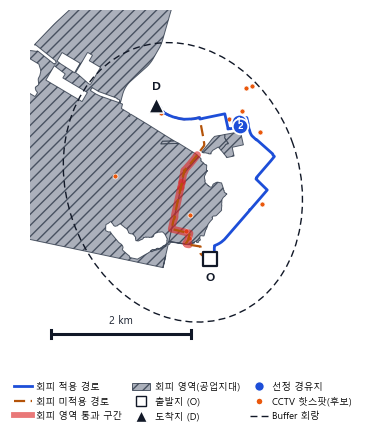

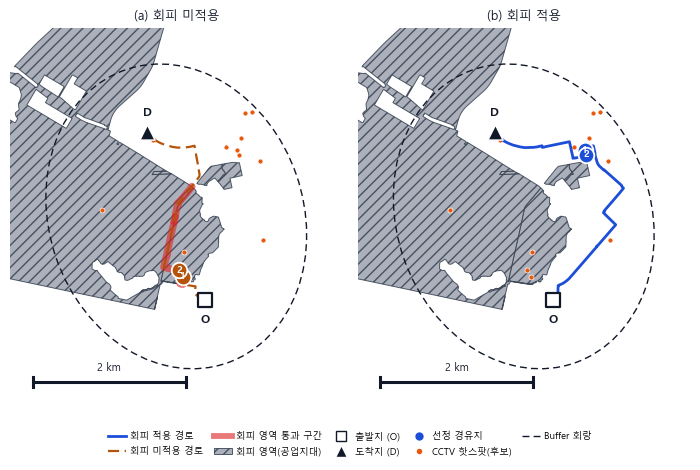


  [저장]
    C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output10_260930\figures\fig_route_V022_k2_single.png
    C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output10_260930\figures\fig_route_V022_k2_single.pdf
    C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output10_260930\figures\fig_route_V022_k2_dual.png
    C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output10_260930\figures\fig_route_V022_k2_dual.pdf

  캡션 예시:
  (그림 N) 경로 추천 및 회피 처리 결과. 회피를 적용하지 않은 경로는 회피 영역을 1771m 통과하나, 제안 방법을 적용한 경로는 0m로 감소하였다.


In [12]:
# ==========================================================================
# 셀 12: 대표 OD 선정 → single·dual 동시 생성 → 저장
# ==========================================================================
# Tmap 호출은 경로 산출 때 한 번만 하고, 그리기만 배치별로 두 번 수행한다.
# 따라서 배치를 둘 다 만들어도 호출 수는 하나일 때와 같다(OD당 최대 6회).

FIG_OD_ID       = None     # 특정 OD를 쓰려면 'V012' 처럼 지정. None이면 자동 선정
FIG_K           = 2        # 경유 핫스팟 수 (논문 확정값)
FIG_DPI         = 300
BASEMAP         = 'osm'          # 배경 지도: 'osm' | 'gray'(Esri 회색) | None(흰 배경)
SHOW_HOTSPOTS   = 'candidates'   # CCTV 핫스팟: 'candidates' | 'all' | None
SHOW_BUFFER     = True           # 타원 회랑 표시. False면 경로 주변만 확대된다

FIG_DIR = V10_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def rank_ods_for_figure(top_n=8):
    """회피 효과가 그림으로 가장 잘 드러나는 OD를 순위화한다.

    1순위  통과가 완전히 제거된 건 (원본 통과가 길수록 위)
    2순위  통과 감소량이 큰 건
    필터   원본 통과 300m 미만은 그림에서 식별되지 않으므로 제외
    """
    if not K2_RESULT_PATH.exists():
        return None
    df = pd.read_csv(K2_RESULT_PATH)
    c = df[(df['group'] == 'adjacent') & (df['orig_cross_m'] >= 300)].copy()
    if len(c) == 0:
        return None
    c['gain_m'] = c['orig_cross_m'] - c['v2_cross_m']
    c['full_removed'] = c['v2_cross_m'] < 1
    c = c.sort_values(['full_removed', 'gain_m'], ascending=[False, False])
    return c.head(top_n)


print("=" * 84)
print("[논문용 경로 그림 생성]")
print("=" * 84)

_rank = rank_ods_for_figure()
if FIG_OD_ID:
    od_id = FIG_OD_ID
    print(f"  수동 지정: {od_id}")
elif _rank is not None:
    cols = ['od_id', 'district', 'orig_cross_m', 'v2_cross_m', 'gain_m',
            'n_swaps', 'hard_case', 'v2_dist_km']
    print("\n  [후보 순위] 위에서부터 회피 효과가 뚜렷하다\n")
    print(_rank[[c for c in cols if c in _rank.columns]].to_string(index=False))
    od_id = _rank.iloc[0]['od_id']
    print(f"\n  자동 선정: {od_id}")
    print("  다른 OD를 쓰려면 FIG_OD_ID에 위 표의 od_id를 넣고 다시 실행한다.")
else:
    adj = [o for o in MIXED_OD if o.get('group') == 'adjacent']
    od_id = max(adj, key=lambda o: o.get('chord_m', 0))['od_id']
    print(f"  자동 선정(폴백): {od_id}")
    print("  k2_result.csv가 없어 직선 통과 길이(chord_m) 기준으로 골랐다.")

od = next(o for o in MIXED_OD if o['od_id'] == od_id)
print(f"\n  OD {od['od_id']} | 군구 {od.get('district')} | "
      f"직선 {od.get('direct_km', 0):.2f}km | 후보 {len(od['candidates'])}곳")

# --- 경로 산출 (Tmap 호출은 여기서 한 번) ---
routes = compute_routes(od, k=FIG_K, gamma=GAMMA)

if not routes['orig_path'] or not routes['avoid_path']:
    raise RuntimeError("경로 산출 실패. 다른 OD를 지정한다.")

_oc = sum(s.length for s in _cross_segments(routes['orig_path'], avoid_union)) * 111000
_ac = sum(s.length for s in _cross_segments(routes['avoid_path'], avoid_union)) * 111000
_res = routes['avoid_res']

print(f"\n  회피 미적용 : 거리 {routes['orig_dist_m']/1000:.2f}km | 통과 {_oc:.0f}m")
print(f"  회피 적용   : 거리 {routes['avoid_dist_m']/1000:.2f}km | 통과 {_ac:.0f}m "
      f"| 후보 교체 {_res['n_swaps']}회 | hard case {_res['hard_case']}")
if _oc > 0:
    print(f"  통과 거리 감소율 : {(_oc - _ac) / _oc * 100:.1f}%")

# --- 두 배치를 모두 생성 ---
saved = []
for layout in ('single', 'dual'):
    fig = draw_route_figure(od, routes, k=FIG_K, layout=layout,
                            basemap=BASEMAP, show_hotspots=SHOW_HOTSPOTS,
                            show_buffer=SHOW_BUFFER)
    for ext in ('png', 'pdf'):
        p = FIG_DIR / f"fig_route_{od['od_id']}_k{FIG_K}_{layout}.{ext}"
        fig.savefig(p, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
        saved.append(p)
    plt.show()

print("\n  [저장]")
for p in saved:
    print(f"    {p.resolve()}")

print("\n  캡션 예시:")
print(f"  (그림 N) 경로 추천 및 회피 처리 결과. 회피를 적용하지 않은 경로는 "
      f"회피 영역을 {_oc:.0f}m 통과하나, 제안 방법을 적용한 경로는 {_ac:.0f}m로 "
      f"감소하였다.")

[후보 5개] ['V022', 'V094', 'V052', 'V026', 'V044']



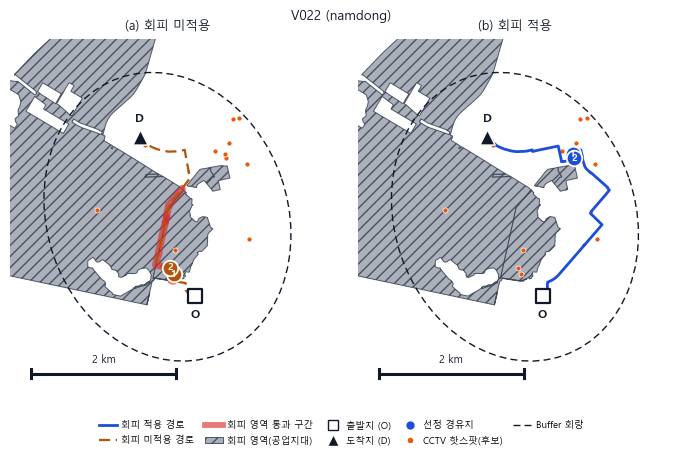

  [저장] cand_V022_k2_dual.png



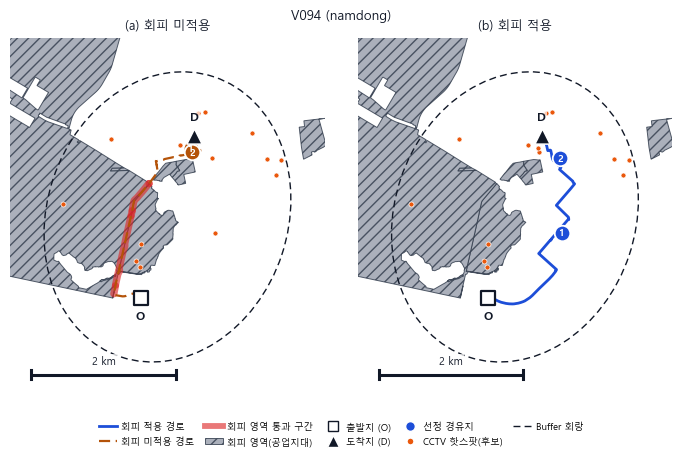

  [저장] cand_V094_k2_dual.png



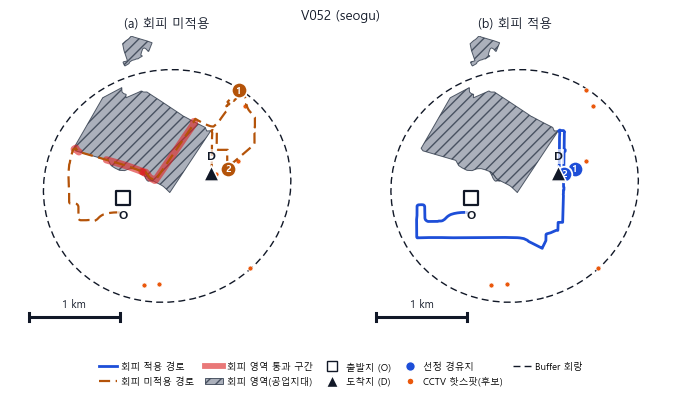

  [저장] cand_V052_k2_dual.png



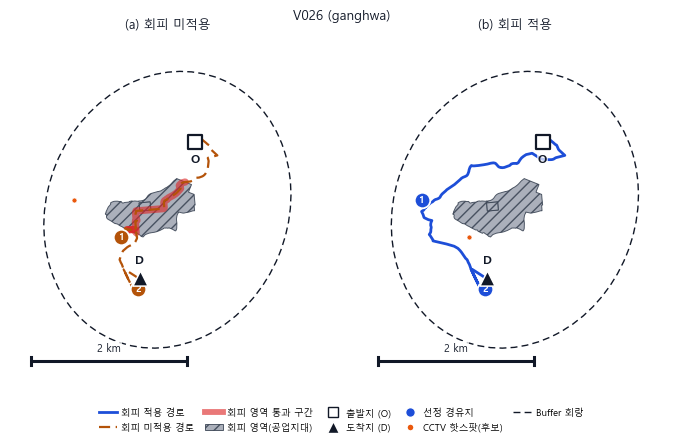

  [저장] cand_V026_k2_dual.png



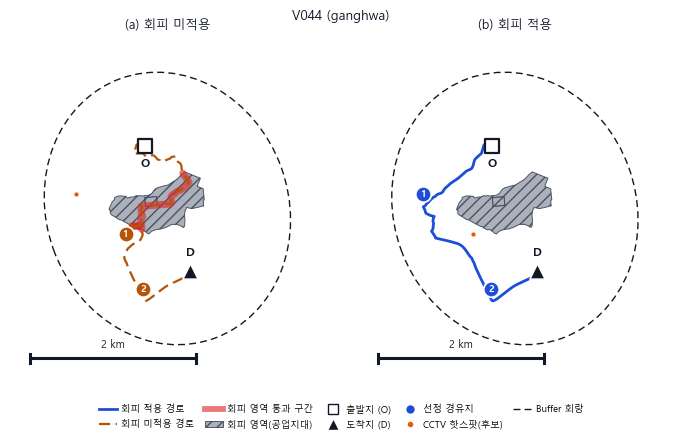

  [저장] cand_V044_k2_dual.png

od_id district  orig_cross_m  avoid_cross_m  reduction_pct  orig_km  avoid_km  n_swaps
 V022  namdong          1771              0          100.0     3.36      4.58        0
 V094  namdong          1701              0          100.0     3.62      3.99        0
 V052    seogu          1654              0          100.0     6.17      4.84        0
 V026  ganghwa          1499              0          100.0     3.79      4.73        1
 V044  ganghwa          1489              0          100.0     4.08      3.62        1

  마음에 드는 od_id를 셀 12의 FIG_OD_ID에 넣고 300dpi로 다시 저장한다.


In [13]:
# ==========================================================================
# 셀 13 (선택): 후보 OD 여러 개를 한 번에 그려 비교
# ==========================================================================
# 셀 12가 고른 1위가 형상까지 가장 좋다는 보장은 없다. 상위 몇 개를 미리 그려
# 두고 고르는 편이 빠르다.
# Tmap 호출: OD당 최대 6회. CAND_N=5면 30회 내외로 한도 부담이 없다.

CAND_N      = 5
CAND_LAYOUT = 'dual'      # 비교 목적이면 dual이 판단하기 쉽다

_r = rank_ods_for_figure(top_n=CAND_N)
if _r is not None:
    cand_ids = list(_r['od_id'])
else:
    adj = sorted([o for o in MIXED_OD if o.get('group') == 'adjacent'],
                 key=lambda o: o.get('chord_m', 0), reverse=True)
    cand_ids = [o['od_id'] for o in adj[:CAND_N]]

print(f"[후보 {len(cand_ids)}개] {cand_ids}\n")

summary = []
for oid in cand_ids:
    od_i = next(o for o in MIXED_OD if o['od_id'] == oid)
    try:
        rt = compute_routes(od_i, k=FIG_K, gamma=GAMMA)
    except Exception as e:
        print(f"  {oid}: 실패 ({type(e).__name__})")
        continue
    if not rt['orig_path'] or not rt['avoid_path']:
        print(f"  {oid}: 경로 없음 (Tmap 미지원 구간)")
        continue

    oc = sum(s.length for s in _cross_segments(rt['orig_path'], avoid_union)) * 111000
    ac = sum(s.length for s in _cross_segments(rt['avoid_path'], avoid_union)) * 111000
    summary.append({'od_id': oid, 'district': od_i.get('district'),
                    'orig_cross_m': round(oc), 'avoid_cross_m': round(ac),
                    'reduction_pct': round((oc - ac) / oc * 100, 1) if oc else 0.0,
                    'orig_km': round(rt['orig_dist_m'] / 1000, 2),
                    'avoid_km': round(rt['avoid_dist_m'] / 1000, 2),
                    'n_swaps': rt['avoid_res']['n_swaps']})

    f = draw_route_figure(od_i, rt, k=FIG_K, layout=CAND_LAYOUT,
                          basemap=BASEMAP, show_hotspots=SHOW_HOTSPOTS,
                          show_buffer=SHOW_BUFFER,
                          title=f"{oid} ({od_i.get('district')})")
    p = FIG_DIR / f"cand_{oid}_k{FIG_K}_{CAND_LAYOUT}.png"
    f.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  [저장] {p.name}\n")

if summary:
    print(pd.DataFrame(summary).to_string(index=False))
    print("\n  마음에 드는 od_id를 셀 12의 FIG_OD_ID에 넣고 300dpi로 다시 저장한다.")

In [14]:
# ==========================================================================
# 셀 14: 대화형 HTML 지도 생성 (교수님 확인용)
# ==========================================================================
# 실제 지도 위에 경로·핫스팟·회피 영역을 얹은 HTML을 만든다. 브라우저에서 열어
# 확대·축소·팝업 확인이 가능하며, 우측 상단 레이어 컨트롤로 항목을 켜고 끌 수 있다.
#
# 논문에 넣는 그림은 셀 12가 만드는 PNG이고, 이 HTML은 검토용이다.
# Tmap을 다시 호출하지 않고 셀 12에서 산출한 routes를 그대로 쓴다.

import folium
from folium.features import DivIcon

HTML_HOTSPOTS = 'nearby'    # 'nearby' 화면 주변 | 'candidates' Buffer 후보만 | 'all' 전체 1,535곳

_O, _D = od['O'], od['D']
_c_lat, _c_lon = (_O[0] + _D[0]) / 2, (_O[1] + _D[1]) / 2

m = folium.Map(location=[_c_lat, _c_lon], zoom_start=14,
               tiles='OpenStreetMap', control_scale=True)

# ---------------------------------------------------------------- 회피 영역
fg_zone = folium.FeatureGroup(name='회피 영역 (공업지대)', show=True)
_lat_pad, _lon_pad = 0.045, 0.055
for p in avoid_polygons:
    minx, miny, maxx, maxy = p['geom'].bounds
    if (maxx < _c_lon - _lon_pad or minx > _c_lon + _lon_pad or
            maxy < _c_lat - _lat_pad or miny > _c_lat + _lat_pad):
        continue
    geom = p['geom']
    for poly in ([geom] if geom.geom_type == 'Polygon' else list(geom.geoms)):
        folium.Polygon([[y, x] for x, y in poly.exterior.coords],
                       color='#374151', weight=1.2, fill=True, fill_color='#9CA3AF',
                       fill_opacity=0.45,
                       popup=folium.Popup(
                           f"<b>회피 영역</b><br>{p.get('uname', '')}<br>"
                           f"코드 {p.get('uqa_code', '')}<br>{p.get('sigg_name', '')}",
                           max_width=220)).add_to(fg_zone)
fg_zone.add_to(m)

# ---------------------------------------------------------------- Buffer 타원
fg_buf = folium.FeatureGroup(name='Buffer 회랑 (후보 추출 범위)', show=True)
_dod = haversine_km(_O, _D)
_a = (_dod + BUFFER_R_KM_V6 * 1.5 / DETOUR_RATIO) / 2
_b = math.sqrt(max(_a ** 2 - (_dod / 2) ** 2, 1e-9))
_ang = math.atan2(_D[0] - _O[0],
                  (_D[1] - _O[1]) * math.cos(math.radians(_c_lat)))
_pts = []
for t in np.linspace(0, 2 * math.pi, 181):
    ex, ey = _a * math.cos(t), _b * math.sin(t)
    rx = ex * math.cos(_ang) - ey * math.sin(_ang)
    ry = ex * math.sin(_ang) + ey * math.cos(_ang)
    _pts.append([_c_lat + ry / 110.574,
                 _c_lon + rx / (111.320 * math.cos(math.radians(_c_lat)))])
folium.Polygon(_pts, color='#111827', weight=1.5, dash_array='6,4',
               fill=False, popup='Buffer 회랑 — 이 범위 안의 핫스팟만 후보가 된다'
               ).add_to(fg_buf)
fg_buf.add_to(m)

# ---------------------------------------------------------------- CCTV 핫스팟
_cand_ids = set(od['candidates']['hotspot_id'])
if HTML_HOTSPOTS == 'candidates':
    _hs = od['candidates']
elif HTML_HOTSPOTS == 'all':
    _hs = hotspots
else:
    _hs = hotspots[(hotspots['latitude'].between(_c_lat - _lat_pad, _c_lat + _lat_pad)) &
                   (hotspots['longitude'].between(_c_lon - _lon_pad, _c_lon + _lon_pad))]

fg_hot = folium.FeatureGroup(name=f'CCTV 핫스팟 ({len(_hs)}곳)', show=True)
for _, r in _hs.iterrows():
    is_cand = r['hotspot_id'] in _cand_ids
    in_zone = bool(r.get('in_avoid_zone', False))
    folium.CircleMarker(
        [r['latitude'], r['longitude']],
        radius=5 if is_cand else 3,
        color='#7F1D1D' if in_zone else ('#EA580C' if is_cand else '#6B7280'),
        weight=1.2, fill=True,
        fill_color='#7F1D1D' if in_zone else ('#EA580C' if is_cand else '#D1D5DB'),
        fill_opacity=0.9 if is_cand else 0.55,
        popup=folium.Popup(
            f"<b>{r['hotspot_id']}</b><br>"
            f"오염도 S_i = {r['S_i']:.2f}<br>"
            f"CCTV {int(r['cctv_count'])}대 · 반경 200m 이웃 {int(r['neighbor_200m'])}곳<br>"
            f"Buffer 후보: {'예' if is_cand else '아니오'}<br>"
            f"회피 영역 내부: {'예' if in_zone else '아니오'}", max_width=240),
        tooltip=r['hotspot_id']).add_to(fg_hot)
fg_hot.add_to(m)

# ---------------------------------------------------------------- 경로
def _add_route(path, name, color, dash, show=True):
    if not path:
        return
    fg = folium.FeatureGroup(name=name, show=show)
    folium.PolyLine([[la, lo] for la, lo in path], color=color, weight=5,
                    opacity=0.85, dash_array=dash, popup=name).add_to(fg)
    for seg in _cross_segments(path, avoid_union):
        folium.PolyLine([[y, x] for x, y in seg.coords], color='#DC2626', weight=9,
                        opacity=0.6, popup='회피 영역 통과 구간').add_to(fg)
    fg.add_to(m)

_add_route(routes['orig_path'],
           f"회피 미적용 경로 ({routes['orig_dist_m']/1000:.2f}km · 통과 {_oc:.0f}m)",
           '#B45309', '10,6')
_add_route(routes['avoid_path'],
           f"회피 적용 경로 ({routes['avoid_dist_m']/1000:.2f}km · 통과 {_ac:.0f}m)",
           '#1D4ED8', None)

# ---------------------------------------------------------------- 경유지·O·D
fg_wp = folium.FeatureGroup(name='선정 경유지', show=True)
for _n, (_, r) in enumerate(routes['avoid_sel'].iterrows(), 1):
    folium.CircleMarker([r['latitude'], r['longitude']], radius=13, color='white',
                        weight=2, fill=True, fill_color='#1D4ED8', fill_opacity=1,
                        popup=folium.Popup(
                            f"<b>경유지 {_n}</b><br>{r['hotspot_id']}<br>"
                            f"S_i = {r['S_i']:.2f}<br>우회 D_i = {r['D_i']:.2f}km<br>"
                            f"회피 페널티 = {r['avoid_penalty_i']:.2f}", max_width=230)
                        ).add_to(fg_wp)
    folium.Marker([r['latitude'], r['longitude']],
                  icon=DivIcon(icon_size=(26, 26), icon_anchor=(13, 13),
                               html=f'<div style="font:bold 12px sans-serif;color:white;'
                                    f'text-align:center;line-height:26px">{_n}</div>')
                  ).add_to(fg_wp)
fg_wp.add_to(m)

folium.Marker(_O, tooltip='출발지 (O)', popup='출발지',
              icon=folium.Icon(color='green', icon='play', prefix='fa')).add_to(m)
folium.Marker(_D, tooltip='도착지 (D)', popup='도착지',
              icon=folium.Icon(color='black', icon='flag-checkered', prefix='fa')).add_to(m)

# ---------------------------------------------------------------- 범례·제목
_red = (_oc - _ac) / _oc * 100 if _oc > 0 else 0.0
_legend = f"""
<div style="position:fixed; bottom:24px; left:24px; z-index:9999;
     background:rgba(255,255,255,.94); border:1px solid #9CA3AF; border-radius:6px;
     padding:10px 13px; font:12px/1.65 'Malgun Gothic',sans-serif; color:#111827;
     box-shadow:0 2px 8px rgba(0,0,0,.18)">
  <div style="font-weight:700; margin-bottom:6px">
    {od['od_id']} · {od.get('district','')} · K={FIG_K}
  </div>
  <span style="display:inline-block;width:26px;height:0;border-top:4px solid #1D4ED8;
        vertical-align:middle"></span> 회피 적용 · {routes['avoid_dist_m']/1000:.2f}km ·
        통과 {_ac:.0f}m<br>
  <span style="display:inline-block;width:26px;height:0;
        border-top:4px dashed #B45309;vertical-align:middle"></span> 회피 미적용 ·
        {routes['orig_dist_m']/1000:.2f}km · 통과 {_oc:.0f}m<br>
  <span style="display:inline-block;width:26px;height:0;border-top:6px solid #DC2626;
        opacity:.6;vertical-align:middle"></span> 회피 영역 통과 구간<br>
  <span style="display:inline-block;width:12px;height:12px;background:#EA580C;
        border-radius:50%;vertical-align:middle"></span> CCTV 핫스팟(후보) &nbsp;
  <span style="display:inline-block;width:12px;height:12px;background:#7F1D1D;
        border-radius:50%;vertical-align:middle"></span> 회피 영역 내부<br>
  <div style="margin-top:6px;padding-top:6px;border-top:1px solid #D1D5DB">
    통과 거리 <b>{_red:.1f}%</b> 감소 · 후보 교체 {routes['avoid_res']['n_swaps']}회
  </div>
  <div style="margin-top:4px;color:#6B7280;font-size:11px">
    핀·선을 눌러 상세를 확인한다. 우측 상단에서 항목을 켜고 끌 수 있다.
  </div>
</div>"""
m.get_root().html.add_child(folium.Element(_legend))
folium.LayerControl(collapsed=False).add_to(m)

_html = FIG_DIR / f"map_{od['od_id']}_k{FIG_K}.html"
m.save(str(_html))
print(f"[HTML 저장] {_html.resolve()}")
print(f"  표시 핫스팟 {len(_hs)}곳 (HTML_HOTSPOTS='{HTML_HOTSPOTS}')")
print("  브라우저로 열어 확인한다. 교수님께는 이 파일 하나만 보내면 된다.")

m   # 노트북에서도 바로 표시된다

[HTML 저장] C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output10_260930\figures\map_V022_k2.html
  표시 핫스팟 223곳 (HTML_HOTSPOTS='nearby')
  브라우저로 열어 확인한다. 교수님께는 이 파일 하나만 보내면 된다.
